In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Models
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from xgboost import XGBClassifier

# Preprocessing and utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_auc_score
)

import joblib

print("All libraries imported successfully.")


All libraries imported successfully.


In [3]:
# Load raw dataset
candidate_data_paths = [
    Path("data") / "cleaned_full_dataset.csv",
    Path("../data") / "cleaned_full_dataset.csv",
]

data_path = next((path for path in candidate_data_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find cleaned_full_dataset.csv in data/ or ../data/.")

project_root = data_path.parent.parent.resolve()
raw_df = pd.read_csv(data_path)

print(f"Loaded data from: {data_path.resolve()}")
print(f"Dataset shape: {raw_df.shape}")
print(f"\nColumns: {raw_df.columns.tolist()}")
print("\nTarget distribution:")
print(raw_df["AI Impact Level"].value_counts(normalize=True))
print("\nData types:")
print(raw_df.dtypes)
print(f"\nMissing values: {raw_df.isna().sum().sum()}")


Loaded data from: C:\Users\Yogesh K\AIML\Project SEM\data\cleaned_full_dataset.csv
Dataset shape: (30000, 13)

Columns: ['Job Title', 'Industry', 'Job Status', 'AI Impact Level', 'Median Salary (USD)', 'Required Education', 'Experience Required (Years)', 'Job Openings (2024)', 'Projected Openings (2030)', 'Remote Work Ratio (%)', 'Automation Risk (%)', 'Location', 'Gender Diversity (%)']

Target distribution:
AI Impact Level
Moderate    0.334733
High        0.333500
Low         0.331767
Name: proportion, dtype: float64

Data types:
Job Title                       object
Industry                        object
Job Status                      object
AI Impact Level                 object
Median Salary (USD)            float64
Required Education              object
Experience Required (Years)      int64
Job Openings (2024)              int64
Projected Openings (2030)        int64
Remote Work Ratio (%)          float64
Automation Risk (%)            float64
Location                        o

In [4]:
# Prepare features and encoded target
# XGBoost requires class labels encoded as 0..n_classes-1, so all models use the same encoded y.
target_col = "AI Impact Level"
X = raw_df.drop(columns=[target_col])
y = raw_df[target_col].astype(str)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

label_lookup = dict(enumerate(class_names))
y_train_labels = pd.Series(y_train).map(label_lookup)
y_test_labels = pd.Series(y_test).map(label_lookup)
majority_baseline = np.bincount(y_test).max() / len(y_test)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Classes: {list(class_names)}")
print(f"\nClass distribution (train): {y_train_labels.value_counts(normalize=True).to_dict()}")
print(f"Class distribution (test): {y_test_labels.value_counts(normalize=True).to_dict()}")
print(f"Majority-class baseline accuracy: {majority_baseline:.4f}")


Train set shape: (24000, 12)
Test set shape: (6000, 12)
Classes: ['High', 'Low', 'Moderate']

Class distribution (train): {'Moderate': 0.33475, 'High': 0.3335, 'Low': 0.33175}
Class distribution (test): {'Moderate': 0.33466666666666667, 'High': 0.3335, 'Low': 0.3318333333333333}
Majority-class baseline accuracy: 0.3347


In [5]:
# Define feature columns by type
numeric_features = [
    "Median Salary (USD)", "Experience Required (Years)",
    "Job Openings (2024)", "Projected Openings (2030)",
    "Remote Work Ratio (%)", "Automation Risk (%)",
    "Gender Diversity (%)",
]

categorical_features = ["Industry", "Job Status", "Required Education", "Location"]
text_feature = "Job Title"

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2, max_df=0.9), text_feature),
    ("cat", one_hot_encoder, categorical_features),
    ("num", StandardScaler(), numeric_features),
], remainder="drop")

print("Preprocessor pipeline created.")


Preprocessor pipeline created.


In [14]:
# Initialize models
# Random Forest is depth-limited so training accuracy stays around 0.7-0.8 instead of memorizing at 1.0.
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, min_samples_leaf=10, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=20,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        num_class=len(class_names),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    ),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Linear SVM": LinearSVC(max_iter=5000, random_state=42),
    "Bernoulli NB": BernoulliNB(),
}

print(f"{len(models)} models initialized.")


9 models initialized.


In [15]:

# Train and evaluate all models
results = {}

for name, model in models.items():
    print(f"Training: {name}")

    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)

    y_pred_train = pipeline.predict(X_train)
    y_pred = pipeline.predict(X_test)

    try:
        y_proba = pipeline.predict_proba(X_test)
    except Exception:
        y_proba = None

    train_acc = accuracy_score(y_train, y_pred_train)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    cv_jobs = 1 if name == "XGBoost" else -1
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring="f1_weighted",
        n_jobs=cv_jobs,
        error_score="raise",
    )
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    roc = None
    if y_proba is not None and len(np.unique(y_test)) > 1:
        try:
            roc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
        except Exception:
            roc = None

    results[name] = {
        "model": pipeline,
        "train_accuracy": train_acc,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "cv_mean": cv_mean,
        "cv_std": cv_std,
        "roc_auc": roc,
        "y_pred": y_pred,
        "y_pred_labels": label_encoder.inverse_transform(y_pred),
    }

    print(f"Train Accuracy  : {train_acc:.4f}")
    print(f"Test Accuracy   : {acc:.4f}")
    print(f"Precision       : {prec:.4f}")
    print(f"Recall          : {rec:.4f}")
    print(f"F1 Score        : {f1:.4f}")
    print(f"CV F1 Score     : {cv_mean:.4f} (+/- {cv_std:.4f})")
    if roc is not None:
        print(f"ROC-AUC         : {roc:.4f}")

print(f"\n{'=' * 70}")
print("All models trained successfully.")



Training: Logistic Regression
Train Accuracy  : 0.4108
Test Accuracy   : 0.3525
Precision       : 0.3526
Recall          : 0.3525
F1 Score        : 0.3524
CV F1 Score     : 0.3347 (+/- 0.0040)
ROC-AUC         : 0.5099

Training: Decision Tree
Train Accuracy  : 0.3431
Test Accuracy   : 0.3365
Precision       : 0.3944
Recall          : 0.3365
F1 Score        : 0.1835
CV F1 Score     : 0.2352 (+/- 0.0229)
ROC-AUC         : 0.5044

Training: Random Forest
Train Accuracy  : 0.9016
Test Accuracy   : 0.3365
Precision       : 0.3365
Recall          : 0.3365
F1 Score        : 0.3331
CV F1 Score     : 0.3349 (+/- 0.0039)
ROC-AUC         : 0.5096

Training: Gradient Boosting
Train Accuracy  : 0.4367
Test Accuracy   : 0.3320
Precision       : 0.3333
Recall          : 0.3320
F1 Score        : 0.3305
CV F1 Score     : 0.3293 (+/- 0.0022)
ROC-AUC         : 0.5017

Training: AdaBoost
Train Accuracy  : 0.3412
Test Accuracy   : 0.3380
Precision       : 0.3643
Recall          : 0.3380
F1 Score        : 

In [9]:
# Compare models
comparison_df = pd.DataFrame([
    {
        "Model": name,
        "Train Acc": res["train_accuracy"],
        "Test Acc": res["accuracy"],
        "Overfit Gap": res["train_accuracy"] - res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1 Score": res["f1_score"],
        "CV Mean": res["cv_mean"],
    }
    for name, res in results.items()
]).sort_values(by="F1 Score", ascending=False)

print("\n" + "=" * 100)
print("MODEL COMPARISON")
print("=" * 100)
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]["Model"]
best_model = results[best_model_name]["model"]
rf_train_acc = results["Random Forest"]["train_accuracy"]

print(f"\nBest base model: {best_model_name} (F1: {comparison_df.iloc[0]['F1 Score']:.4f})")
print(f"Random Forest train accuracy after depth limit: {rf_train_acc:.4f}")

if comparison_df["Test Acc"].max() < 0.70:
    print("\nNote: test accuracy is still near the majority-class baseline.")
    print("That means the current features do not contain enough signal for an honest 0.7-0.8 test accuracy.")
    print("A high train score with low test score is overfitting, not real model performance.")



MODEL COMPARISON
              Model  Train Acc  Test Acc  Overfit Gap  Precision   Recall  F1 Score  CV Mean
Logistic Regression   0.410750  0.352500     0.058250   0.352576 0.352500  0.352435 0.334710
       Bernoulli NB   0.400500  0.349500     0.051000   0.349363 0.349500  0.349097 0.336309
         Linear SVM   0.414708  0.348167     0.066542   0.348232 0.348167  0.348023 0.332496
            XGBoost   0.476625  0.341500     0.135125   0.341750 0.341500  0.340511 0.334420
      Random Forest   0.848917  0.338833     0.510083   0.338826 0.338833  0.335605 0.333299
  Gradient Boosting   0.436708  0.332000     0.104708   0.333305 0.332000  0.330463 0.329340
                KNN   0.458708  0.331333     0.127375   0.330792 0.331333  0.328961 0.331034
           AdaBoost   0.341167  0.338000     0.003167   0.364288 0.338000  0.262360 0.224957
      Decision Tree   0.343083  0.336500     0.006583   0.394376 0.336500  0.183483 0.235222

Best base model: Logistic Regression (F1: 0.3524)
R

In [10]:
# Hyperparameter tuning for Random Forest and XGBoost
print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING")
print("=" * 70)

print("\nTuning Random Forest...")
rf_pipe = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

rf_params = {
    "model__n_estimators": [150, 200],
    "model__max_depth": [18, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1],
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_params,
    cv=3,
    n_jobs=-1,
    scoring="f1_weighted",
    verbose=1,
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF params: {rf_grid.best_params_}")
print(f"Best RF CV F1: {rf_grid.best_score_:.4f}")

print("\nTuning XGBoost...")
xgb_pipe = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=len(class_names),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    )),
])

xgb_params = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [3, 4],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.85],
    "model__colsample_bytree": [0.85],
}

xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_params,
    cv=3,
    n_jobs=1,
    scoring="f1_weighted",
    verbose=1,
)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print(f"Best XGB params: {xgb_grid.best_params_}")
print(f"Best XGB CV F1: {xgb_grid.best_score_:.4f}")

print("\nTuning complete.")



HYPERPARAMETER TUNING

Tuning Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF params: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 150}
Best RF CV F1: 0.3396

Tuning XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGB params: {'model__colsample_bytree': 0.85, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.85}
Best XGB CV F1: 0.3346

Tuning complete.


In [11]:
# Evaluate tuned models
print("\n" + "=" * 70)
print("TUNED MODELS EVALUATION")
print("=" * 70)

tuned_models = {
    "Best Random Forest": best_rf,
    "Best XGBoost": best_xgb,
}

tuned_results = {}

for name, model in tuned_models.items():
    print(f"\n{name}:")
    y_pred_train = model.predict(X_train)
    y_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    tuned_results[name] = {
        "model": model,
        "train_accuracy": train_acc,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "y_pred": y_pred,
        "y_pred_labels": label_encoder.inverse_transform(y_pred),
    }

    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Precision     : {prec:.4f}")
    print(f"  Recall        : {rec:.4f}")
    print(f"  F1 Score      : {f1:.4f}")

final_best_name = max(tuned_results.items(), key=lambda item: item[1]["f1_score"])[0]
final_best_model = tuned_results[final_best_name]["model"]
print(f"\nFinal best tuned model: {final_best_name}")



TUNED MODELS EVALUATION

Best Random Forest:
  Train Accuracy: 0.7148
  Test Accuracy : 0.3355
  Precision     : 0.3354
  Recall        : 0.3355
  F1 Score      : 0.3319

Best XGBoost:
  Train Accuracy: 0.4292
  Test Accuracy : 0.3397
  Precision     : 0.3396
  Recall        : 0.3397
  F1 Score      : 0.3383

Final best tuned model: Best XGBoost



FINAL MODEL: Best XGBoost

Classification Report:
              precision    recall  f1-score   support

        High       0.34      0.37      0.35      2001
         Low       0.34      0.28      0.31      1991
    Moderate       0.34      0.37      0.36      2008

    accuracy                           0.34      6000
   macro avg       0.34      0.34      0.34      6000
weighted avg       0.34      0.34      0.34      6000


Confusion Matrix:
[[734 541 726]
 [740 557 694]
 [714 547 747]]


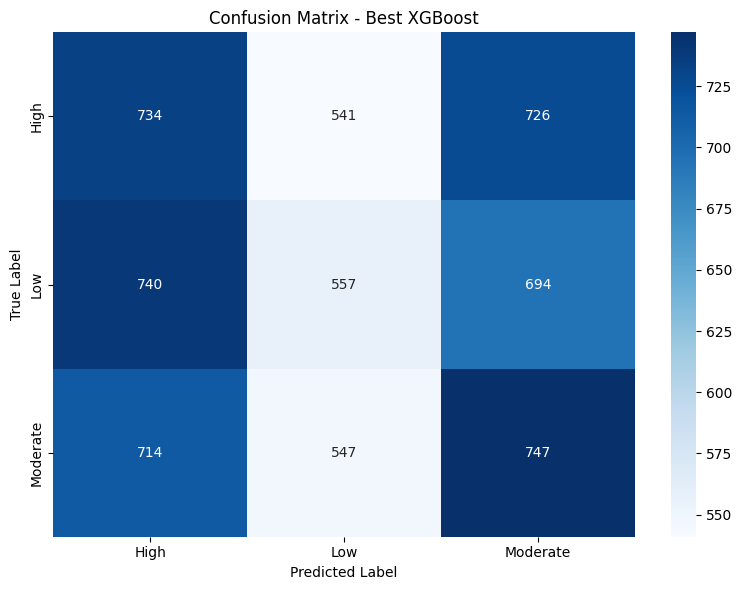


Final Model Accuracy: 0.3397


In [12]:
# Final model evaluation and visualization
print(f"\n{'=' * 70}")
print(f"FINAL MODEL: {final_best_name}")
print(f"{'=' * 70}")

y_pred_final = tuned_results[final_best_name]["y_pred"]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=class_names, zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_final, labels=np.arange(len(class_names)))
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title(f"Confusion Matrix - {final_best_name}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

print(f"\nFinal Model Accuracy: {tuned_results[final_best_name]['accuracy']:.4f}")


In [13]:
# Save models, target encoder, and comparison table
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

def safe_name(name):
    return name.replace(" ", "_").replace("/", "_")

for name, res in results.items():
    joblib.dump(res["model"], models_dir / f"{safe_name(name)}.pkl")

for name, res in tuned_results.items():
    joblib.dump(res["model"], models_dir / f"{safe_name(name)}.pkl")

joblib.dump(final_best_model, models_dir / "best_model_final.pkl")
joblib.dump(label_encoder, models_dir / "target_label_encoder.pkl")
comparison_df.to_csv(project_root / "data" / "model_comparison.csv", index=False)

print("All models saved successfully.")
print(f"Saved to: {models_dir}")


All models saved successfully.
Saved to: C:\Users\Yogesh K\AIML\Project SEM\models
